In [1]:
library(e1071)
library(caret)
library(pROC)

Loading required package: ggplot2


Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element


Loading required package: lattice

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




In [11]:
# data <- read.csv("../Pima-Indians-Diabetes-Dataset/diabetes_imputed.csv")


train <- read.csv("../Pima-Indians-Diabetes-Dataset/train_data_imputed.csv")
test <- read.csv("../Pima-Indians-Diabetes-Dataset/test_data_imputed.csv")

In [13]:
train$Outcome <- as.factor(train$Outcome)
test$Outcome  <- as.factor(test$Outcome)

In [15]:
x_train <- train[, -9]
y_train <- train$Outcome

x_test <- test[, -9]
y_test <- test$Outcome

In [16]:
train_scaled <- scale(x_train)

In [17]:
train_center <- attr(train_scaled, "scaled:center")
train_scale  <- attr(train_scaled, "scaled:scale")

In [18]:
test_scaled <- scale(
    x_test,
    center = train_center,
    scale = train_scale
)

### Linear SVM

In [19]:
svm_linear <- svm(
    x = train_scaled,
    y = y_train,
    kernel = "linear",
    cost = 1,
    probability = TRUE
)

In [20]:
pred_linear <- predict(
    svm_linear,
    test_scaled
)

In [21]:
cm_linear <- confusionMatrix(
    pred_linear,
    y_test
)

cm_linear

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 90 16
         1 12 36
                                          
               Accuracy : 0.8182          
                 95% CI : (0.7481, 0.8757)
    No Information Rate : 0.6623          
    P-Value [Acc > NIR] : 1.32e-05        
                                          
                  Kappa : 0.5857          
                                          
 Mcnemar's Test P-Value : 0.5708          
                                          
            Sensitivity : 0.8824          
            Specificity : 0.6923          
         Pos Pred Value : 0.8491          
         Neg Pred Value : 0.7500          
             Prevalence : 0.6623          
         Detection Rate : 0.5844          
   Detection Prevalence : 0.6883          
      Balanced Accuracy : 0.7873          
                                          
       'Positive' Class : 0               
                                    

In [22]:
cm_linear$overall["Accuracy"]

Accuracy 
0.8181818

In [38]:
precision <- cm_linear$byClass["Pos Pred Value"]

recall <- cm_linear$byClass["Sensitivity"]

F1 <- 2 * precision * recall /
      (precision + recall)

precision
recall
F1

Pos Pred Value 
     0.8490566

Sensitivity 
  0.8823529

Pos Pred Value 
     0.8653846

In [27]:
prob_linear <- attr(
    predict(
        svm_linear,
        test_scaled,
        probability = TRUE
    ),
    "probabilities"
)[, 2]

In [28]:
roc_linear <- roc(
    y_test,
    prob_linear
)

auc(roc_linear)

Setting levels: control = 0, case = 1

Setting direction: controls > cases



Area under the curve: 0.8842

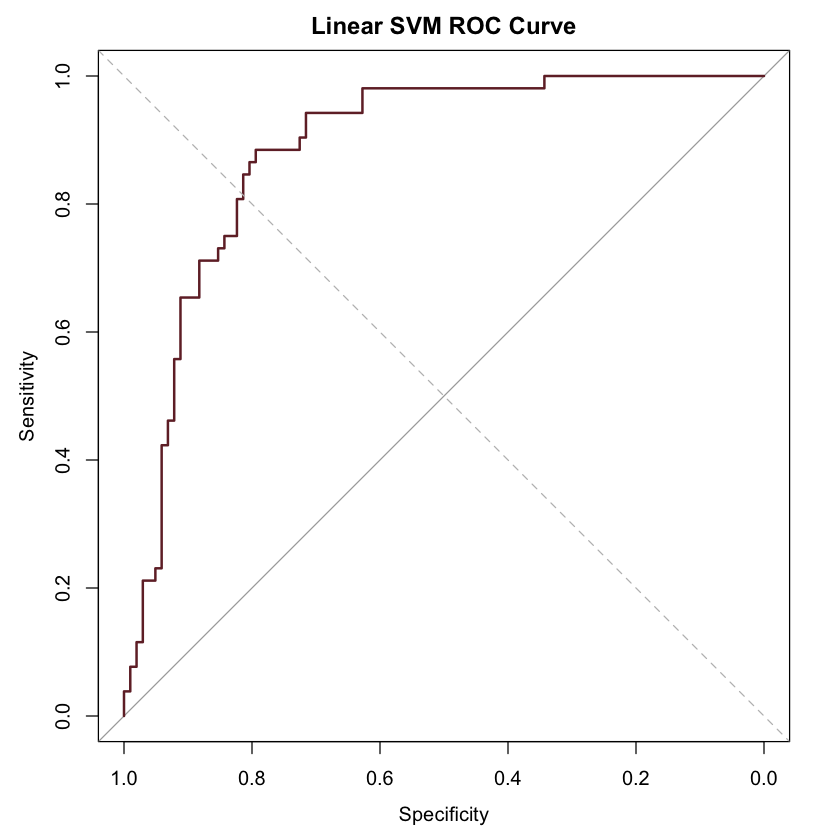

In [30]:
par(bg = "White")

plot(
    roc_linear,
    col = "#712A31",
    lwd = 2,
    main = "Linear SVM ROC Curve"
)

abline(0, 1, lty = 2, col = "gray")

### Radial SVM

In [31]:
svm_radial <- svm(
    x = train_scaled,
    y = y_train,
    kernel = "radial",
    cost = 1,
    gamma = 0.1,
    probability = TRUE
)

In [32]:
pred_radial <- predict(
    svm_radial,
    test_scaled
)

In [33]:
cm_radial <- confusionMatrix(
    pred_radial,
    y_test
)

cm_radial

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 93 12
         1  9 40
                                          
               Accuracy : 0.8636          
                 95% CI : (0.7991, 0.9136)
    No Information Rate : 0.6623          
    P-Value [Acc > NIR] : 1.164e-08       
                                          
                  Kappa : 0.6908          
                                          
 Mcnemar's Test P-Value : 0.6625          
                                          
            Sensitivity : 0.9118          
            Specificity : 0.7692          
         Pos Pred Value : 0.8857          
         Neg Pred Value : 0.8163          
             Prevalence : 0.6623          
         Detection Rate : 0.6039          
   Detection Prevalence : 0.6818          
      Balanced Accuracy : 0.8405          
                                          
       'Positive' Class : 0               
                                    

In [34]:
prob_radial <- attr(
    predict(
        svm_radial,
        test_scaled,
        probability = TRUE
    ),
    "probabilities"
)[, 2]

In [35]:
roc_radial <- roc(
    y_test,
    prob_radial
)

auc(roc_radial)

Setting levels: control = 0, case = 1

Setting direction: controls > cases



Area under the curve: 0.9023

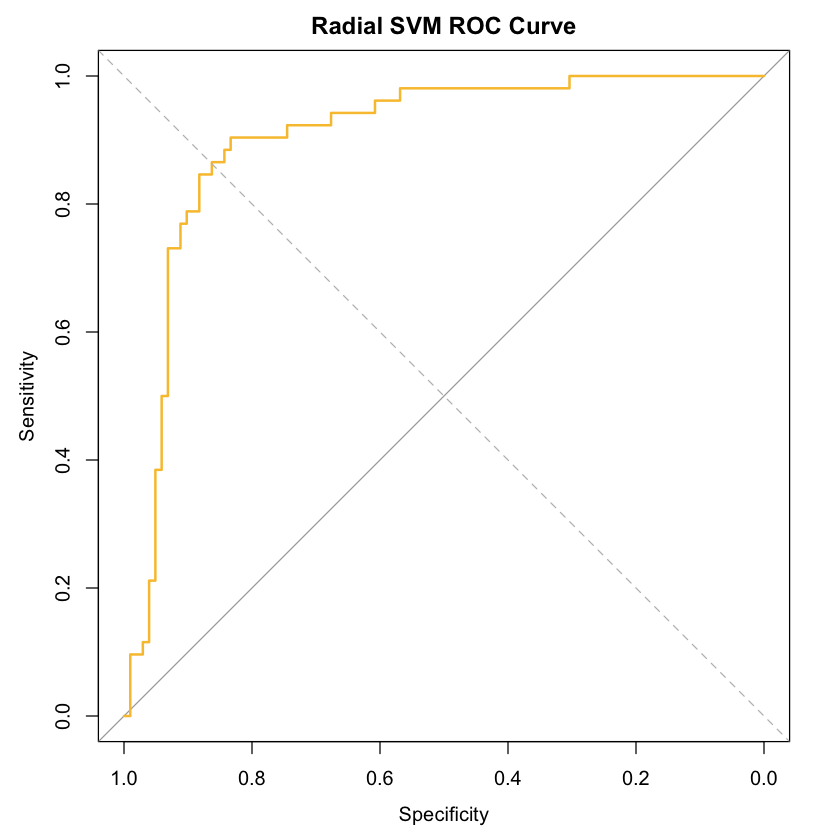

In [37]:
par(bg = "White")

plot(
    roc_radial,
    col = "#F8C23A",
    lwd = 2,
    main = "Radial SVM ROC Curve"
)

abline(0, 1, lty = 2, col = "gray")